# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 003 - BERT-based NER Tagger

> Notebook by:
> - NLP Course Stuff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 2026       | |


## Overview
In this assignment, you will further work on assignment 2, that is, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using BERT, this time.

**This assignment is not mandatory, we will take the 3/4 best grades, but we recomment you doing it.**

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on those links so you have access to the data!**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

Please create a local copy of this template Colab's Notebook.

The assignment's instructions are there; follow the notebook.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




In [1]:
!mkdir data
# Fetch data
# train_link = 'https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing'
# dev_link   = 'https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing'
# test_link  = 'https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing'

!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf' -O data/train.txt
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1rdUida-j3OXcwftITBlgOh8nURhAYUDw' -O data/dev.txt
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=137Ht40OfflcsE6BIYshHbT5b2iIJVaDx' -O data/test.txt


In [2]:
# Any additional needed libraries
!pip install -qU transformers[torch] wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 144.4 MB/s eta 0:00:00


In [3]:
# Standard Library Imports
import os
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional
import json
from google.colab import files

# ML
import numpy as np
import scipy as sp
import pandas as pd

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support


In [4]:
model_name = 'bert-base-uncased'
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# Set up the device
DEVICE = "cuda" if th.cuda.is_available() else "cpu"
# assert DEVICE == "cuda"

DataType = dict[str, list[list[str]]]

# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- The function returns a dictionary of the texts as a list and the tags as a list.

Example output:
```
{
  "texts": [
    ['At','Trent','Bridge',':'],
    ...],
  "tags":[
    ['O','B-LOC','I-LOC ','O'],
    ...]
  ...
}
```

In [5]:
def read_data(filepath:str) -> DataType:
  """
  Read data from a single file.
  The function recieves a filepath
  The funtion encodes every sentence using a pair of lists, one list contains the words and one list contains the tags.
  :param filepath: path to the file
  :return: data as a list of tuples
  """
  data = {
    "texts": [],
    "tags": []
  }
  # TO DO ----------------------------------------------------------------------
  words, tags = [], []
  with open(filepath, 'r', encoding='utf-8') as f:
      for line in f:
          line = line.strip()
          if not line:
              if words:
                  data["texts"].append(words)
                  data["tags"].append(tags)
                  words, tags = [], []
          else:
              parts = line.split()
              if len(parts) >= 2:
                  words.append(parts[0])
                  tags.append(parts[-1])
  if words:
      data["texts"].append(words)
      data["tags"].append(tags)
  # TO DO ----------------------------------------------------------------------
  return data

In [6]:
train_raw = read_data("data/train.txt")
dev_raw = read_data("data/dev.txt")
test_raw = read_data("data/test.txt")
print(f"Train size: {len(train_raw['texts'])}")
print(f"Dev size: {len(dev_raw['texts'])}")
print(f"Test size: {len(test_raw['texts'])}")

Train size: 1750
Dev size: 250
Test size: 500


## Step 2: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test], and encodes it to tensors.

### Your Task
1. Load the BERT Tokenizer
2. Tokenize the data and encode the labels

In [7]:
# Prepare tag2id dictionaries
tag2id = {}
id2tag = {}
tags = ["O", "B-PER", "I-PER", "B-LOC", "I-LOC", "B-ORG", "I-ORG"]
for tag in tags:
  tag2id[tag] = len(tag2id)
  id2tag[len(id2tag)] = tag

In [8]:
tag2id

{'O': 0,
 'B-PER': 1,
 'I-PER': 2,
 'B-LOC': 3,
 'I-LOC': 4,
 'B-ORG': 5,
 'I-ORG': 6}

In [9]:
tokenizer = None
# TO DO ----------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(model_name)
# TO DO ----------------------------------------------------------------------
tokenizer

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [10]:
def prepare_data(data: DataType, tag2id: dict[str, int]) -> dict[str, th.Tensor]:
  enc_data = {
    "texts": None,
    "labels": None
  }
  # TO DO ----------------------------------------------------------------------
  # Tokenize the texts
  tokenized_inputs = tokenizer(
        data["texts"],
        is_split_into_words=True,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

  labels = []
  for i, tags in enumerate(data["tags"]):
      # word_ids maps subwords back to their original word index
      word_ids = tokenized_inputs.word_ids(batch_index=i)
      previous_word_idx = None
      label_ids = []

      for word_idx in word_ids:
          # Special tokens like [CLS] and [SEP] map to None
          if word_idx is None:
              label_ids.append(-100)
          # Only label the first subword of a given word
          elif word_idx != previous_word_idx:
              label_ids.append(tag2id[tags[word_idx]])
          # Assign -100 to subsequent subwords so they are ignored in the loss
          else:
              label_ids.append(-100)
          previous_word_idx = word_idx

      labels.append(label_ids)

  enc_data["texts"] = tokenized_inputs
  enc_data["labels"] = th.tensor(labels)
  # TO DO ----------------------------------------------------------------------
  return enc_data

In [11]:
train_sequences = prepare_data(train_raw, tag2id)
dev_sequences = prepare_data(dev_raw, tag2id)
test_sequences = prepare_data(test_raw, tag2id)

## Step 3: Dataset
Create datasets for each split in the dataset. They should return the samples as Tensors.


In [12]:
class NERDataset(Dataset):
  # TO DO ----------------------------------------------------------------------
  def __init__(self, enc_data):
      self.enc_data = enc_data

  def __len__(self):
      return len(self.enc_data["labels"])

  def __getitem__(self, idx):
      item = {k: v[idx] for k, v in self.enc_data["texts"].items()}
      item["labels"] = self.enc_data["labels"][idx]
      return item
  # TO DO ----------------------------------------------------------------------

In [13]:
train_ds = None
dev_ds = None
test_ds = None
# TO DO ----------------------------------------------------------------------
train_ds = NERDataset(train_sequences)
dev_ds = NERDataset(dev_sequences)
test_ds = NERDataset(test_sequences)
# TO DO ----------------------------------------------------------------------

<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Load Model

Load a token classification model.

In [14]:
model = None
def load_model(model_name: str, tag2id) -> nn.Module:
# TO DO ----------------------------------------------------------------------
    id2tag = {v: k for k, v in tag2id.items()}
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(tag2id),
        id2label=id2tag,
        label2id=tag2id
    )
    return model
# TO DO ----------------------------------------------------------------------
model = load_model(model_name, tag2id)
model

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

## Step 2: Training

Write a training function that utilizes the huggingface Trainer. The function should log the loss of both train dataset and the dev one every here and there.

In [15]:
N_EPOCHS = 5
# TO DO ----------------------------------------------------------------------
BATCH_SIZE = 16
# TO DO ----------------------------------------------------------------------

In [16]:
def train_model(model, n_epochs: int, batch_size: int, train_ds: Dataset, dev_ds: Dataset) -> Trainer:
  """
  Train a model.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param batch_size: batch size
  :param train_ds: train dataset
  :param dev_ds: dev dataset
  :return: loss and accuracy during training
  """
  # TO DO ----------------------------------------------------------------------
  training_args = TrainingArguments(
      output_dir="./results",
      eval_strategy="epoch",
      save_strategy="epoch",
      learning_rate=2e-5,
      per_device_train_batch_size=batch_size,
      per_device_eval_batch_size=batch_size,
      num_train_epochs=n_epochs,
      weight_decay=0.01,
      load_best_model_at_end=True,
      metric_for_best_model="eval_loss",
      logging_steps=15,
      report_to="wandb"
  )

  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_ds,
      eval_dataset=dev_ds
  )

  trainer.train()
  return trainer
  # TO DO ----------------------------------------------------------------------

In [17]:
import wandb

wandb.login()
wandb.init(project="Assignment_3_BERT")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yonatan-benzvi (yonatan-benzvi-reichman-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [18]:
wandb.watch(model, log_freq=15)
trainer = train_model(model, N_EPOCHS, BATCH_SIZE, train_ds, dev_ds)

Epoch,Training Loss,Validation Loss
1,0.170511,0.137594
2,0.068062,0.071686
3,0.029876,0.053946
4,0.015577,0.057528
5,0.018891,0.057429


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation function for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: True Positive Rate (TPR), also known as Recall.
- **Precision**: The opposite of False Positive Rate (FPR), also known as Precision.
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [19]:
def evaluate(trainer: Trainer, title: str, dataset: Dataset, tag2id: dict[str, int]):
  """
  Evaluate a trained model on the given dataset.
  :param trainer: trainer instance containing a trained model
  :param title: title for the plot
  :param dataset: dataset
  :param tag2id: tag2id dictionary
  :return: Dictionary of evaluation results
  """
  results = {}
  # TO DO ----------------------------------------------------------------------
  predictions, labels, _ = trainer.predict(dataset)
  predictions = np.argmax(predictions, axis=2)

  # Remove ignored index (special tokens)
  true_predictions = [
      [p for (p, l) in zip(prediction, label) if l != -100]
      for prediction, label in zip(predictions, labels)
  ]
  true_labels = [
      [l for (p, l) in zip(prediction, label) if l != -100]
      for prediction, label in zip(predictions, labels)
  ]

  # Flatten the lists for scikit-learn metrics
  flat_preds = [p for sublist in true_predictions for p in sublist]
  flat_labels = [l for sublist in true_labels for l in sublist]

  id2tag = {v: k for k, v in tag2id.items()}
  labels_list = list(range(len(tag2id)))
  target_names = [id2tag[i] for i in labels_list]

  # All Labels
  prec, rec, f1, _ = precision_recall_fscore_support(
      flat_labels, flat_preds, average='weighted', zero_division=0
  )

  # All Labels Except 'O'
  o_id = tag2id.get('O')
  labels_wo_o = [v for k, v in tag2id.items() if k != 'O']
  prec_wo_o, rec_wo_o, f1_wo_o, _ = precision_recall_fscore_support(
      flat_labels, flat_preds, labels=labels_wo_o, average='weighted', zero_division=0
  )

  # Confusion Matrix Plot
  cm = confusion_matrix(flat_labels, flat_preds, labels=labels_list)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
  plt.title(title or "Confusion Matrix")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.show()

  results = {
      'RECALL': rec, 'PRECISION': prec, 'F1': f1,
      'RECALL_WO_O': rec_wo_o, 'PRECISION_WO_O': prec_wo_o, 'F1_WO_O': f1_wo_o
  }

  df_res = pd.DataFrame([results])
  print(f"\n--- Evaluation Results for {title} ---")
  print(tabulate(df_res, headers='keys', tablefmt='psql', floatfmt=".4f"))
  # TO DO ----------------------------------------------------------------------
  return results


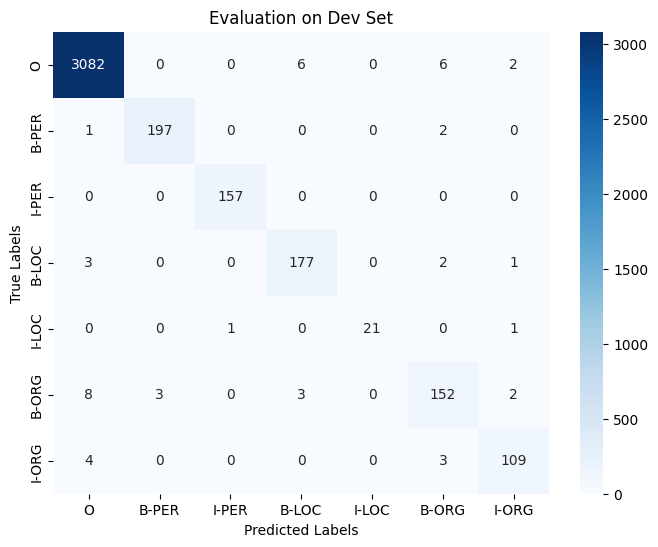


--- Evaluation Results for Evaluation on Dev Set ---
+----+----------+-------------+--------+---------------+------------------+-----------+
|    |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+----------+-------------+--------+---------------+------------------+-----------|
|  0 |   0.9878 |      0.9878 | 0.9878 |        0.9599 |           0.9621 |    0.9609 |
+----+----------+-------------+--------+---------------+------------------+-----------+


In [20]:
# Assuming model is trained, and dl_dev is the DataLoader for dev dataset
results = evaluate(trainer, "Evaluation on Dev Set", dev_ds, tag2id)

## Step 2 - Logs and Visualization
Explore and intagrate [wandb](https://wandb.ai/home) as a logging and visualization tool. Integrate it in the training and evaluation steps. Look for the plots of the loss (train, eval) and see how useful it can be :) Also make sure to log some results, such as plots and funal results before printing.

## Step 3: Development
Experiment your training with diffenet Hyperparameters and optimize them based on the results on the **development set**.

Decide which model performs the best. Note that this time the parameters changes will be inside the model initialization or the train functions and will not be given as parameters to the load_model function. So just hard-code them in the other functions.


🚀 Starting Run: Learning Rate: 2e-05 | Batch Size: 16


eval/loss,█▂▁▁▁
eval/runtime,▃▆▁▅█
eval/samples_per_second,▆▃█▄▁
eval/steps_per_second,▆▃█▄▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
+3,...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.138293,0.121156,0.959446,0.964240,0.961498
2,0.062982,0.071521,0.980726,0.980472,0.980539
3,0.026420,0.058025,0.983651,0.983515,0.983551
4,0.015026,0.057892,0.985802,0.985544,0.985643
5,0.016748,0.057065,0.986311,0.986051,0.986152


...


Run bert-ner-lr3e-05-bs32 finished with Validation F1: 0.9879


eval/f1,▁▇█▇██
eval/loss,█▂▁▁▁▁
eval/precision,▁▇████
eval/recall,▁▇█▇██
eval/runtime,█▅▄▆▇▁
eval/samples_per_second,▁▄▅▃▂█
eval/steps_per_second,▁▄▅▃▂█
train/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▇▇▇▇████
train/global_step,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▇▇▇▇████
train/grad_norm,▄▃▅▃▄▂▃▁▃▇▃▂▁▃▃▃█▁
+2,...



Hyperparameter Search Complete!
Best Validation F1 Score: 0.9891
Best Hyperparameters: {'learning_rate': 3e-05, 'batch_size': 16}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Visualizing Best Model on Dev Set:


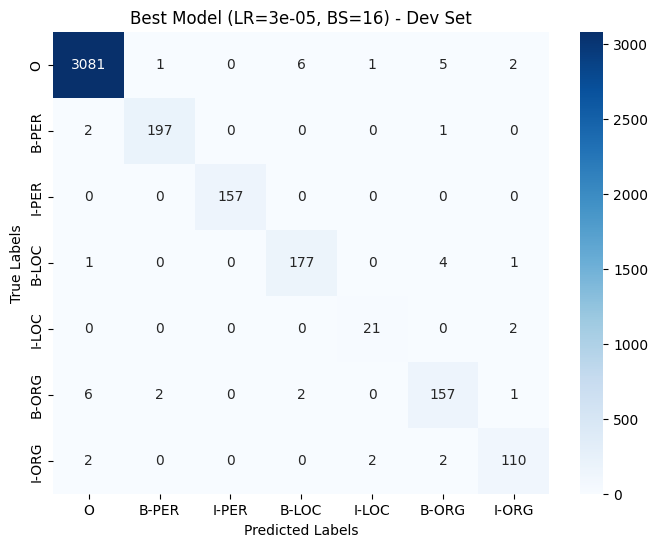


--- Evaluation Results for Best Model (LR=3e-05, BS=16) - Dev Set ---
+----+----------+-------------+--------+---------------+------------------+-----------+
|    |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+----------+-------------+--------+---------------+------------------+-----------|
|  0 |   0.9891 |      0.9892 | 0.9891 |        0.9669 |           0.9626 |    0.9647 |
+----+----------+-------------+--------+---------------+------------------+-----------+


In [21]:
# TO DO ----------------------------------------------------------------------
from transformers import EarlyStoppingCallback

learning_rates = [2e-5, 3e-5]
batch_sizes = [16, 32]

def compute_metrics(p):
    """
    Calculates precision, recall, and F1 on the fly during training.
    """
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [p for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [l for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    flat_preds = [p for sublist in true_predictions for p in sublist]
    flat_labels = [l for sublist in true_labels for l in sublist]

    prec, rec, f1, _ = precision_recall_fscore_support(
        flat_labels, flat_preds, average='weighted', zero_division=0
    )
    return {
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

def run_hyperparameter_search(train_ds, dev_ds, tag2id):
    best_f1 = 0.0
    best_model_path = "./results_best_ner_model"
    best_hyperparams = {}

    for lr in learning_rates:
        for bs in batch_sizes:
            run_name = f"bert-ner-lr{lr}-bs{bs}"
            print(f"\n{'='*60}")
            print(f"🚀 Starting Run: Learning Rate: {lr} | Batch Size: {bs}")
            print(f"{'='*60}")

            wandb.init(project="Assignment_3_BERT", name=run_name, reinit="finish_previous")

            current_model = load_model(model_name, tag2id)

            training_args = TrainingArguments(
                output_dir=f"./results_{run_name}",
                eval_strategy="epoch",
                save_strategy="epoch",
                learning_rate=lr,
                per_device_train_batch_size=bs,
                per_device_eval_batch_size=bs,
                num_train_epochs=N_EPOCHS,
                weight_decay=0.01,
                load_best_model_at_end=True,
                metric_for_best_model="f1",
                logging_steps=15,
                report_to="wandb"
            )

            trainer = Trainer(
                model=current_model,
                args=training_args,
                train_dataset=train_ds,
                eval_dataset=dev_ds,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
            )

            trainer.train()

            eval_metrics = trainer.evaluate()
            current_f1 = eval_metrics.get("eval_f1", 0)

            print(f"\nRun {run_name} finished with Validation F1: {current_f1:.4f}")

            if current_f1 > best_f1:
                print(f"New best model found! F1 improved from {best_f1:.4f} to {current_f1:.4f}")
                best_f1 = current_f1
                best_hyperparams = {"learning_rate": lr, "batch_size": bs}

                trainer.save_model(best_model_path)

            wandb.finish()

    print(f"\n{'='*60}")
    print(f"Hyperparameter Search Complete!")
    print(f"Best Validation F1 Score: {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_hyperparams}")
    print(f"{'='*60}")

    return best_hyperparams, best_model_path

best_params, best_path = run_hyperparameter_search(train_ds, dev_ds, tag2id)

best_model = AutoModelForTokenClassification.from_pretrained(best_path)

best_training_args = TrainingArguments(
    output_dir="./final_eval",
    per_device_eval_batch_size=best_params["batch_size"],
    report_to="none" # Skip W&B logging for this raw wrap
)

best_trainer = Trainer(
    model=best_model,
    args=best_training_args,
    eval_dataset=dev_ds,
    compute_metrics=compute_metrics
)

print("\nVisualizing Best Model on Dev Set:")
best_dev_results = evaluate(best_trainer, f"Best Model (LR={best_params['learning_rate']}, BS={best_params['batch_size']}) - Dev Set", dev_ds, tag2id)
# TO DO ----------------------------------------------------------------------

## Step 4 - Final Evaluation
After configring your params such that the model loaded is the best one,train it, evaluate it on the test set and print the results. This part simulates the real world data.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Training final model...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.082038,0.978046,0.977936,0.977536
2,No log,0.053723,0.985359,0.985290,0.985234
3,No log,0.051194,0.987526,0.987573,0.987533
4,No log,0.053581,0.986374,0.986305,0.986305
5,0.090157,0.053913,0.988629,0.988587,0.988593


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

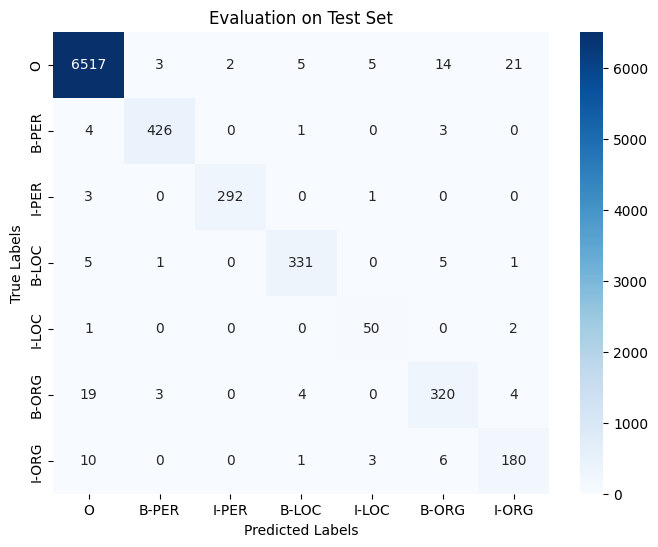


--- Evaluation Results for Evaluation on Test Set ---
+----+----------+-------------+--------+---------------+------------------+-----------+
|    |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+----------+-------------+--------+---------------+------------------+-----------|
|  0 |   0.9846 |      0.9848 | 0.9847 |        0.9541 |           0.9503 |    0.9521 |
+----+----------+-------------+--------+---------------+------------------+-----------+


In [22]:
model = None
# TO DO ----------------------------------------------------------------------
model = load_model(model_name, tag2id)

BEST_LR = 3e-5
BEST_BATCH_SIZE = 16

final_training_args = TrainingArguments(
    output_dir="./results_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=BEST_LR,
    per_device_train_batch_size=BEST_BATCH_SIZE,
    per_device_eval_batch_size=BEST_BATCH_SIZE,
    num_train_epochs=N_EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

final_trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Training final model...")
final_trainer.train()

results_test = evaluate(final_trainer, "Evaluation on Test Set", test_ds, tag2id)
# TO DO ----------------------------------------------------------------------

<br><br><br><br><br>

# Testing

Before running the tests:
1. Create a **sharing link** to your notebook with **editor access**.
2. Paste it in the `NOTEBOOK_LINK` variable below.

Then run the test cells to create the `results.json` file.


In [24]:
NOTEBOOK_LINK = "https://colab.research.google.com/drive/1bwkGjuyFrtJ1bVaYn5cWD41h_BlZGpgR?usp=sharing"


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Epoch,Training Loss,Validation Loss
1,0.138293,0.121156
2,0.062982,0.071521
3,0.026420,0.058025
4,0.015026,0.057892
5,0.016748,0.057065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

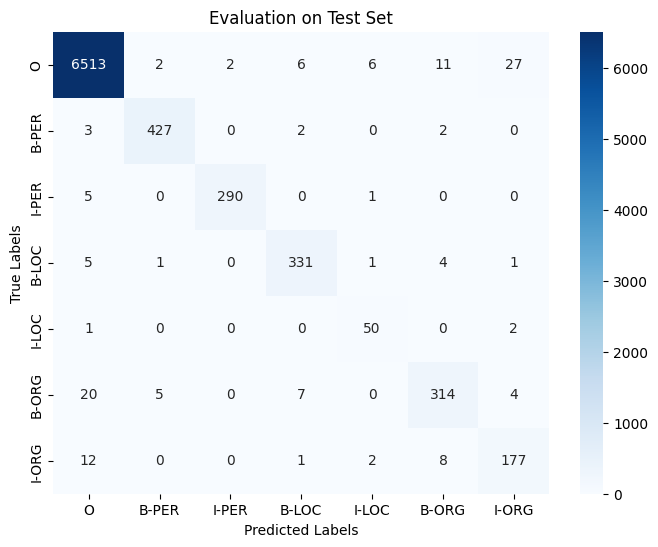


--- Evaluation Results for Evaluation on Test Set ---
+----+----------+-------------+--------+---------------+------------------+-----------+
|    |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+----------+-------------+--------+---------------+------------------+-----------|
|  0 |   0.9829 |      0.9832 | 0.9830 |        0.9481 |           0.9447 |    0.9461 |
+----+----------+-------------+--------+---------------+------------------+-----------+


In [25]:
########################################
# Tests

def test_link():
    return {
        'link': NOTEBOOK_LINK
    }

train_raw = read_data("data/train.txt")
dev_raw = read_data("data/dev.txt")
test_raw = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_raw["texts"]), len(dev_raw["texts"]), len(test_raw["texts"])),
    }
    return result

train_sequences = prepare_data(train_raw, tag2id)
dev_sequences = prepare_data(dev_raw, tag2id)
test_sequences = prepare_data(test_raw, tag2id)

def test_prepare_data():
    result = {
        'dev_texts_shape': dev_sequences["texts"]["input_ids"].shape,
        'train_labels_shape': train_sequences["labels"].shape,
    }
    return result

train_ds = NERDataset(train_sequences)
dev_ds = NERDataset(dev_sequences)
test_ds = NERDataset(test_sequences)

N_EPOCHS = 5
def test_model():
    # Create model
    model = load_model(model_name, tag2id)

    # Train model and evaluate
    trainer = train_model(model, N_EPOCHS, BATCH_SIZE, train_ds, dev_ds)

    results_eval = evaluate(trainer, "Evaluation on Test Set", test_ds, tag2id)

    return {
        'f1': results_eval['F1'],
        'f1_wo_o': results_eval['F1_WO_O'],
    }

TESTS = [
    test_link,
    test_read_data,
    test_prepare_data,
    test_model,
]

# Run tests and save results
res = {}
for test in TESTS:
    try:
        cur_res = test()
        res.update({test.__name__: cur_res})
    except Exception as e:
        import traceback
        res.update({test.__name__: repr(e) + "\n" + traceback.format_exc()})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)

########################################


---

# 📤 Submit Your Assignment to GitHub

## Step 1: Authentication Setup (One-Time)

Before you can submit, you need to set up GitHub authentication.

### Creating a GitHub Personal Access Token:

1. **Go to GitHub Token Settings**: [https://github.com/settings/tokens](https://github.com/settings/tokens)

2. **Click "Generate new token (classic)"**

3. **Configure your token**:
   - **Note**: "NLP Course Assignments" (or any name you like)
   - **Expiration**: 90 days (or custom)
   - **Select scopes**: Check **`repo`** (full control of private repositories)

4. **Click "Generate token"**

5. **IMPORTANT**: Copy the token immediately and save it somewhere safe!
   - Like Colab Secrets (see picture)
   - You won't be able to see it again
   - You can reuse this token for all assignments
   - Don't share it with anyone

### Run the authentication cell below

You only need to do this **once per Colab session**. If you restart the runtime, you'll need to re-run the authentication cell.

---


In [26]:
"""
GitHub Authentication Setup
Run this cell ONCE to set up your GitHub credentials
"""

import os
from getpass import getpass

def setup_github_auth():
    """Set up GitHub credentials - run once per Colab session"""
    global GITHUB_USERNAME, GITHUB_TOKEN

    print("🔐 GitHub Authentication Setup")
    print("=" * 60)

    GITHUB_USERNAME = input("GitHub username: ")
    GITHUB_TOKEN = getpass("GitHub Personal Access Token (hidden): ")

    print("\n✅ Credentials saved for this session!")
    print("You can now run the submission cell below.")
    print("\n💡 Tip: Your credentials are only stored in this runtime.")
    print("If you restart the runtime, you'll need to run this cell again.")

# Run the setup
setup_github_auth()


🔐 GitHub Authentication Setup
GitHub username: JonyBenZvi
GitHub Personal Access Token (hidden): ··········

✅ Credentials saved for this session!
You can now run the submission cell below.

💡 Tip: Your credentials are only stored in this runtime.
If you restart the runtime, you'll need to run this cell again.


---

## Step 2: Submit Your Results

Once you've:
- ✅ Completed all the code cells above
- ✅ Run all the test cells
- ✅ Generated `results.json`
- ✅ Run the authentication cell

You can now submit your assignment by running the cell below!

### What you'll need:
- Your **GitHub Classroom repository URL**
  - You received this when you accepted the assignment
  - Format: `https://github.com/NLP-Reichman/2026-assignment-3-team-name`
- (Optional) A custom commit message

### After submission:
- Check your repository to see `results.json` has been uploaded
- Visit the **Actions** tab to see your autograding results
- Results typically appear within 1-2 minutes

---


In [27]:
"""
Submit Assignment to GitHub
Run this cell to push your results.json to GitHub
"""

import os
import subprocess
import json

def check_credentials():
    """Check if credentials are set"""
    try:
        _ = GITHUB_USERNAME
        _ = GITHUB_TOKEN
        return True
    except NameError:
        print("❌ GitHub credentials not found!")
        print("Please run the authentication cell above first.")
        return False


def check_results_file():
    """Check if results.json exists"""
    if not os.path.exists('results.json'):
        print("❌ results.json not found!")
        print("\nPlease run all the test cells above to generate results.json")
        return False

    # Display test summary
    try:
        with open('results.json', 'r') as f:
            results = json.load(f)

        print("📊 Test Results Found:")
        print("-" * 60)
        for test_name in results.keys():
            print(f"  ✓ {test_name}")
        print("-" * 60)
        return True
    except Exception as e:
        print(f"⚠️  Warning: Could not read results.json: {e}")
        return True  # Still allow submission


def submit_to_github(repo_url, commit_message=None):
    """Submit results.json to GitHub repository"""

    if commit_message is None:
        commit_message = "Submit assignment results from Colab"

    print("\n🚀 Submitting to GitHub...")
    print("=" * 60)

    # Create temporary directory
    temp_dir = '/content/github_submission'
    if os.path.exists(temp_dir):
        subprocess.run(['rm', '-rf', temp_dir], check=True, capture_output=True)

    os.makedirs(temp_dir, exist_ok=True)
    os.chdir(temp_dir)

    try:
        # Configure git
        subprocess.run(['git', 'config', '--global', 'user.email',
                       f'{GITHUB_USERNAME}@users.noreply.github.com'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'config', '--global', 'user.name',
                       GITHUB_USERNAME],
                      check=True, capture_output=True)

        # Clone repository with authentication
        auth_url = repo_url.replace('https://', f'https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@')

        print("📥 Cloning repository...")
        result = subprocess.run(['git', 'clone', auth_url, 'repo'],
                              capture_output=True, text=True)

        if result.returncode != 0:
            print(f"❌ Error cloning repository:")
            print(result.stderr)
            print("\n💡 Troubleshooting:")
            print("  - Check that your repository URL is correct")
            print("  - Verify your token has 'repo' scope")
            print("  - Make sure you've accepted the assignment")
            return False

        # Change to repo directory
        os.chdir('repo')

        # Copy results.json
        print("📝 Copying results.json...")
        subprocess.run(['cp', '/content/results.json', 'results.json'],
                      check=True, capture_output=True)

        # Check for changes
        status = subprocess.run(['git', 'status', '--porcelain'],
                              capture_output=True, text=True)

        if not status.stdout.strip():
            print("\nℹ️  No changes detected - results.json is unchanged")
            print("✅ Your repository is already up to date!")
            return True

        # Commit and push
        print(f"💬 Commit message: '{commit_message}'")
        print("📤 Pushing to GitHub...")

        subprocess.run(['git', 'add', 'results.json'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'commit', '-m', commit_message],
                      check=True, capture_output=True)
        subprocess.run(['git', 'push'],
                      check=True, capture_output=True)

        print("\n" + "=" * 60)
        print("✅ SUCCESS! Assignment submitted!")
        print("=" * 60)
        print(f"\n📊 Repository: {repo_url}")
        print(f"📊 Autograding: {repo_url.replace('.git', '')}/actions")
        print("\n💡 Your grade will appear in the Actions tab in ~1 minute")

        return True

    except subprocess.CalledProcessError as e:
        print(f"\n❌ Git error occurred")
        if hasattr(e, 'stderr') and e.stderr:
            print(f"Details: {e.stderr}")
        return False
    except Exception as e:
        print(f"\n❌ Unexpected error: {e}")
        return False
    finally:
        # Return to /content
        os.chdir('/content')


def main():
    """Main submission workflow"""
    print("=" * 60)
    print("📤 Assignment Submission")
    print("=" * 60)

    # Check credentials
    if not check_credentials():
        return

    # Check results file
    if not check_results_file():
        return

    # Get repository URL
    print("\n📍 Enter your GitHub Classroom repository URL")
    print("Example: https://github.com/NLP-Reichman/2026-assignment-3-username")
    repo_url = input("\nRepository URL: ").strip()

    # Validate URL
    if not repo_url.startswith('https://github.com/'):
        print("❌ Invalid URL - must start with https://github.com/")
        return

    # Get commit message (optional)
    print("\n💬 Commit Message (optional)")
    print("Press Enter for default message, or type your own:")
    commit_msg = input("Message: ").strip()

    if not commit_msg:
        commit_msg = "Submit assignment results from Colab"

    # Confirm submission
    print("\n" + "=" * 60)
    print("Ready to submit:")
    print(f"  Repository: {repo_url}")
    print(f"  File: results.json")
    print(f"  Message: {commit_msg}")
    print("=" * 60)

    confirm = input("\nProceed? (yes/no): ").strip().lower()

    if confirm in ['yes', 'y']:
        success = submit_to_github(repo_url, commit_msg)
        if success:
            print("\n🎉 All done!")
    else:
        print("\n❌ Submission cancelled")


# Run submission
main()


📤 Assignment Submission
📊 Test Results Found:
------------------------------------------------------------
  ✓ test_link
  ✓ test_read_data
  ✓ test_prepare_data
  ✓ test_model
------------------------------------------------------------

📍 Enter your GitHub Classroom repository URL
Example: https://github.com/NLP-Reichman/2026-assignment-3-username

Repository URL: https://github.com/NLP-Reichman/assignment-3-bert-yoni-jony

💬 Commit Message (optional)
Press Enter for default message, or type your own:
Message: Final submission 30/06

Ready to submit:
  Repository: https://github.com/NLP-Reichman/assignment-3-bert-yoni-jony
  File: results.json
  Message: Final submission 30/06

Proceed? (yes/no): yes

🚀 Submitting to GitHub...
📥 Cloning repository...
📝 Copying results.json...
💬 Commit message: 'Final submission 30/06'
📤 Pushing to GitHub...

✅ SUCCESS! Assignment submitted!

📊 Repository: https://github.com/NLP-Reichman/assignment-3-bert-yoni-jony
📊 Autograding: https://github.com/NL